<h1 style="font-size:40px;">🚗 Car Resale Price Prediction</h1>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
df=pd.read_csv("cardekho.csv")

In [ ]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


<h2 style="font-size:15px; font-weight:bold;">
📊 Dataset Statistical Summary
</h2>

In [ ]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


<h2 style="font-size:15px; font-weight:bold;">
📝 Dataset Structure & Information
</h2>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


<h2 style="font-size:15px; font-weight:bold;">
Check Missing values
</h2>

In [ ]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [ ]:
df.rename(columns={'mileage(km/ltr/kg)':'mileage'},inplace=True)

<h2 style="font-size:15px;">Handling the Missing Values</h2>

In [ ]:
df["mileage"]=df["mileage"].fillna(df["mileage"].median())

In [ ]:
df["engine"]=df["engine"].fillna(df["engine"].median())

In [ ]:
df["seats"]=df["seats"].fillna(df["seats"].median())

In [ ]:
df["max_power"]=df["max_power"].str.extract('(\d+\.\d+)').astype(float)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_21396\1753832060.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df["max_power"]=df["max_power"].str.extract('(\d+\.\d+)').astype(float)


In [ ]:
df["max_power"]=df["max_power"].fillna(df["max_power"].median())

In [ ]:
df.duplicated().sum()

np.int64(1202)

In [ ]:
df.drop_duplicates(inplace=True)

<h2 style="font-size:30px;">📊 Exploratory Data Analysis (EDA)</h2>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14


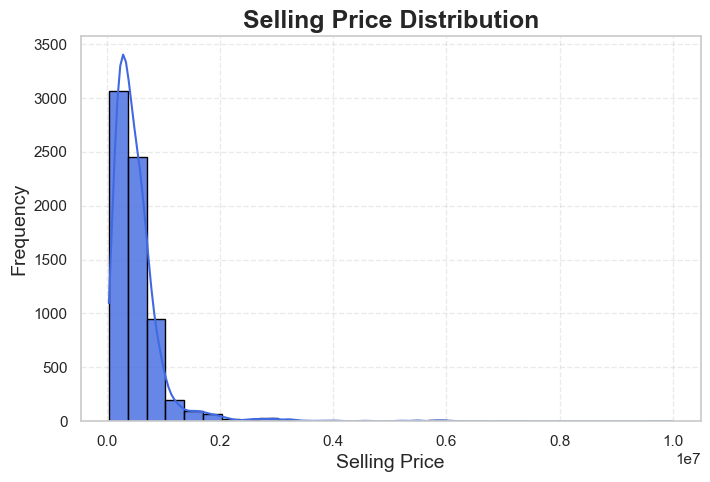

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["selling_price"],
    bins=30,
    kde=True,
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

plt.title("Selling Price Distribution", fontweight="bold")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21396\3086326206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


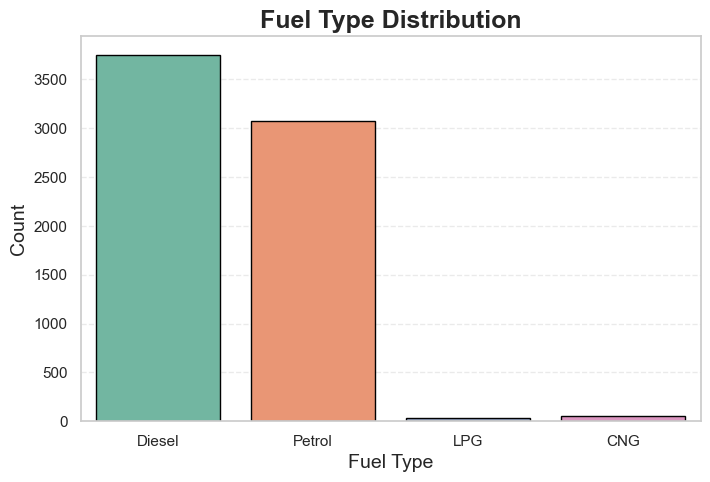

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="fuel",
    data=df,
    palette="Set2",
    edgecolor="black"
)

plt.title("Fuel Type Distribution", fontweight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

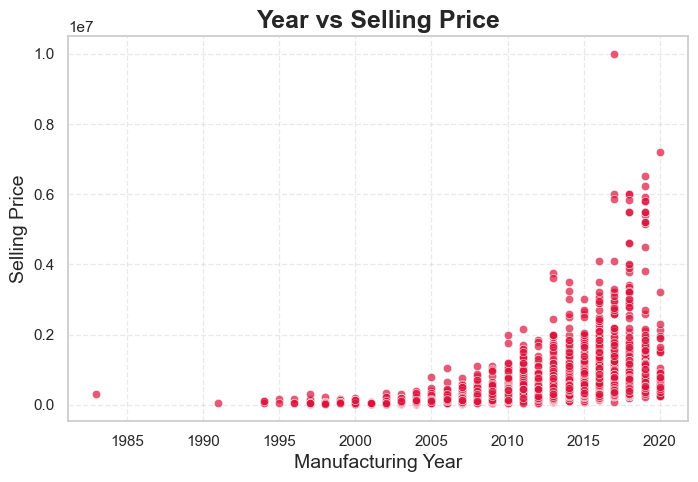

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="year",
    y="selling_price",
    data=df,
    color="crimson",
    alpha=0.7
)

plt.title("Year vs Selling Price", fontweight="bold")
plt.xlabel("Manufacturing Year")
plt.ylabel("Selling Price")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

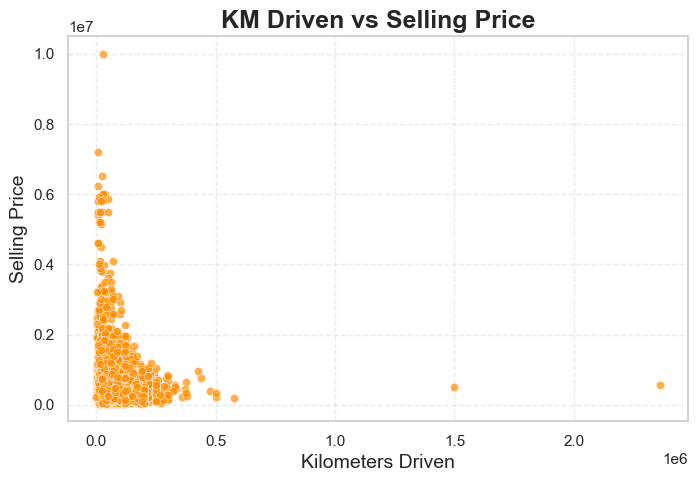

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="km_driven",
    y="selling_price",
    data=df,
    color="darkorange",
    alpha=0.7
)

plt.title("KM Driven vs Selling Price", fontweight="bold")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21396\1094689912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


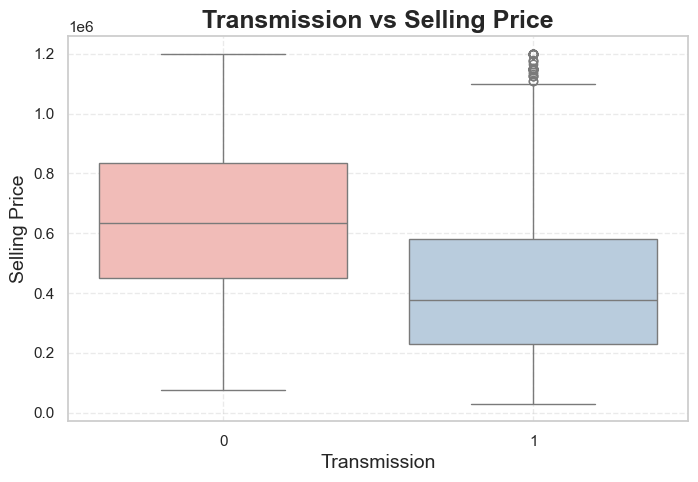

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="transmission",
    y="selling_price",
    data=df,
    palette="Pastel1"
)

plt.title("Transmission vs Selling Price", fontweight="bold")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

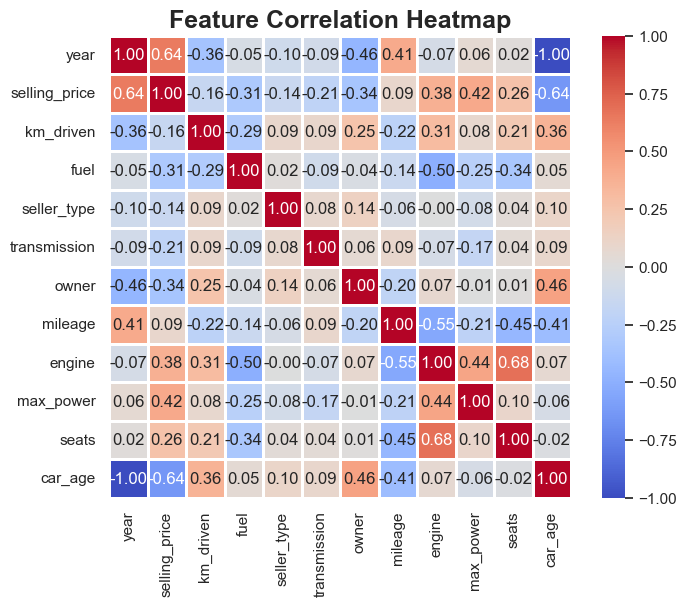

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=1,
    square=True
)

plt.title("Feature Correlation Heatmap", fontweight="bold")

plt.show()

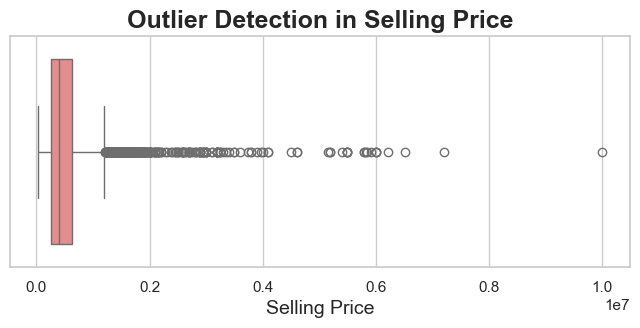

In [ ]:
plt.figure(figsize=(8,3))

sns.boxplot(
    x=df["selling_price"],
    color="lightcoral"
)

plt.title("Outlier Detection in Selling Price", fontweight="bold")
plt.xlabel("Selling Price")

plt.show()

In [ ]:
Q1=df["selling_price"].quantile(0.25)
Q3=df["selling_price"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[(df["selling_price"]>=lower)& (df["selling_price"]<=upper)]

In [ ]:
df['car_age'] = 2026 - df['year']


<h2 style="font-size:15px;font-weight:bold;">Label Encoding</h2>

In [ ]:
le=LabelEncoder()
df["fuel"]=le.fit_transform(df["fuel"])
df["seller_type"]=le.fit_transform(df["seller_type"])
df["transmission"]=le.fit_transform(df["transmission"])
df["owner"]=le.fit_transform(df["owner"])

In [ ]:
df.drop("name",axis=1,inplace=True)

<h2 style="font-size:15px; font-weight:bold;">
🎯 Feature Selection
</h2>

In [ ]:
selected_features = [
    'engine',
    'car_age',
    'year',
    'max_power',
    'mileage',
    'km_driven',
    'transmission',
    'fuel',
    'seller_type'
]

In [ ]:
x=df[selected_features]
y=df["selling_price"]

<h2 style="font-size:15px; font-weight:bold;">✂️ Train-Test Data Splitting
</h2>

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

<h2 style="font-size:15px; font-weight:bold;">
⚖️ Feature Scaling
</h2>

In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


<h2 style="font-size:15px; font-weight:bold;">📈 Linear Regression Model
</h2>

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
accuracy=r2_score(y_test, y_pred)

<h2 style="font-size:15px; font-weight:bold;">📉 Lasso Regression Model
</h2>

In [ ]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
accu=r2_score(y_test,lasso_pred)

<h2 style="font-size:15px; font-weight:bold;">📊 Ridge Regression Model
</h2>

In [ ]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)


<h2 style="font-size:15px; font-weight:bold;"> Regression Models Comparison
</h2>

In [ ]:
print("Linear Regression:", r2_score(y_test, y_pred))

print("Ridge Regression:", r2_score(y_test, ridge_pred))

print("Lasso Regression:", r2_score(y_test, lasso_pred))

Linear Regression: 0.645253707028381
Ridge Regression: 0.645257644212164
Lasso Regression: 0.6452537011707651


<h2 style="font-size:15px; font-weight:bold;">🌲 Random Forest Regressor
</h2>

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
acc=r2_score(y_test, rf_pred)

In [ ]:
print(acc)

0.867109361464218


<h2 style="font-size:15px; font-weight:bold;">📉 Actual vs Predicted Price Visualization
</h2>

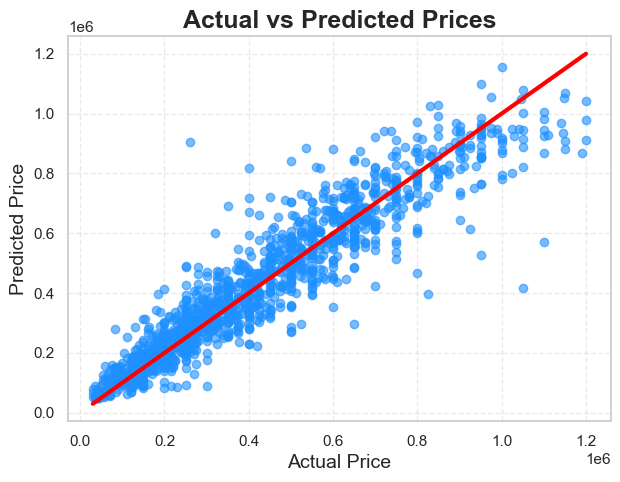

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    rf_pred,
    color="dodgerblue",
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=3
)

plt.title("Actual vs Predicted Prices", fontweight="bold")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()